# UTS Soft Computing - Tahap 3
ANN untuk optimasi parameter MF pada FIS Tahap 1.

## Tujuan
- Latih ANN untuk mempelajari pola risiko kredit.
- Gunakan output ANN sebagai teacher untuk tuning parameter Membership Function (MF) FIS Tahap 1.

In [30]:
!pip install scikit-fuzzy scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import json
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, confusion_matrix

In [32]:
df = pd.read_csv("../data/credit_risk_dataset.csv")

df_clean = df.copy()
df_clean = df_clean[df_clean["person_age"] <= 80]
df_clean = df_clean[df_clean["person_emp_length"] <= 60]

df_clean["person_emp_length"].fillna(df_clean["person_emp_length"].median(), inplace=True)
df_clean["loan_int_rate"].fillna(df_clean["loan_int_rate"].median(), inplace=True)

df_clean = df_clean.reset_index(drop=True)

print(f"Shape setelah cleaning: {df_clean.shape}")
print(f"Missing values setelah cleaning:\n{df_clean.isnull().sum()}")

Shape setelah cleaning: (31677, 12)
Missing values setelah cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


C:\Users\luthf\AppData\Local\Temp\ipykernel_22152\2311357885.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["person_emp_length"].fillna(df_clean["person_emp_length"].median(), inplace=True)
C:\Users\luthf\AppData\Local\Temp\ipykernel_22152\2311357885.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [33]:
features = df_clean[["loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]].copy()
target = df_clean["loan_status"].astype(int).copy()

print("Statistik fitur:")
print(features.describe())
print(f"\nDistribusi target:\n{target.value_counts()}")

Statistik fitur:
       loan_int_rate  loan_percent_income  cb_person_cred_hist_length
count   31677.000000         31677.000000                31677.000000
mean       11.035034             0.169609                    5.807968
std         3.070238             0.106270                    4.056804
min         5.420000             0.000000                    2.000000
25%         8.490000             0.090000                    3.000000
50%        10.990000             0.150000                    4.000000
75%        13.160000             0.230000                    8.000000
max        23.220000             0.830000                   30.000000

Distribusi target:
loan_status
0    24852
1     6825
Name: count, dtype: int64


## Definisi MF awal (Tahap 1) dan output FIS

In [34]:
# Universe of discourse
x_int_rate = np.arange(5, 24, 0.1)
x_pct_income = np.arange(0, 0.85, 0.01)
x_cred_hist = np.arange(2, 31, 1)
x_risk = np.arange(0, 1.01, 0.01)

# Parameter MF awal dari Tahap 1
base_params = {
    "loan_int_rate": {
        "low": [5.0, 5.0, 11.0],
        "medium": [8.0, 13.0, 18.0],
        "high": [15.0, 23.0, 23.0]
    },
    "loan_percent_income": {
        "low": [0.00, 0.00, 0.22],
        "medium": [0.15, 0.30, 0.45],
        "high": [0.38, 0.83, 0.83]
    },
    "cb_person_cred_hist_length": {
        "short": [2.0, 2.0, 7.0],
        "medium": [4.0, 10.0, 16.0],
        "long": [12.0, 30.0, 30.0]
    }
}

# Output MF (tetap)
mf_risk_safe = fuzz.trimf(x_risk, [0.0, 0.0, 0.4])
mf_risk_caution = fuzz.trimf(x_risk, [0.2, 0.5, 0.8])
mf_risk_risky = fuzz.trimf(x_risk, [0.6, 1.0, 1.0])

In [35]:
def build_mfs(params):
    mfs = {
        "rate": {
            "low": fuzz.trimf(x_int_rate, params["loan_int_rate"]["low"]),
            "medium": fuzz.trimf(x_int_rate, params["loan_int_rate"]["medium"]),
            "high": fuzz.trimf(x_int_rate, params["loan_int_rate"]["high"])
        },
        "pct": {
            "low": fuzz.trimf(x_pct_income, params["loan_percent_income"]["low"]),
            "medium": fuzz.trimf(x_pct_income, params["loan_percent_income"]["medium"]),
            "high": fuzz.trimf(x_pct_income, params["loan_percent_income"]["high"])
        },
        "hist": {
            "short": fuzz.trimf(x_cred_hist, params["cb_person_cred_hist_length"]["short"]),
            "medium": fuzz.trimf(x_cred_hist, params["cb_person_cred_hist_length"]["medium"]),
            "long": fuzz.trimf(x_cred_hist, params["cb_person_cred_hist_length"]["long"])
        }
    }
    return mfs

In [36]:
rules = [
    {"rate": "low", "pct": "low", "hist": "long", "risk": "safe"},
    {"rate": "low", "pct": "low", "hist": "medium", "risk": "safe"},
    {"rate": "low", "pct": "low", "hist": "short", "risk": "caution"},
    {"rate": "low", "pct": "medium", "hist": "long", "risk": "safe"},
    {"rate": "low", "pct": "medium", "hist": "medium", "risk": "caution"},
    {"rate": "low", "pct": "medium", "hist": "short", "risk": "caution"},
    {"rate": "low", "pct": "high", "hist": "long", "risk": "caution"},
    {"rate": "low", "pct": "high", "hist": "medium", "risk": "risky"},
    {"rate": "low", "pct": "high", "hist": "short", "risk": "risky"},
    {"rate": "medium", "pct": "low", "hist": "long", "risk": "safe"},
    {"rate": "medium", "pct": "low", "hist": "medium", "risk": "caution"},
    {"rate": "medium", "pct": "low", "hist": "short", "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "long", "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "medium", "risk": "caution"},
    {"rate": "medium", "pct": "medium", "hist": "short", "risk": "risky"},
    {"rate": "medium", "pct": "high", "hist": "long", "risk": "caution"},
    {"rate": "medium", "pct": "high", "hist": "medium", "risk": "risky"},
    {"rate": "medium", "pct": "high", "hist": "short", "risk": "risky"},
    {"rate": "high", "pct": "low", "hist": "long", "risk": "caution"},
    {"rate": "high", "pct": "low", "hist": "medium", "risk": "caution"},
    {"rate": "high", "pct": "low", "hist": "short", "risk": "risky"},
    {"rate": "high", "pct": "medium", "hist": "long", "risk": "caution"},
    {"rate": "high", "pct": "medium", "hist": "medium", "risk": "risky"},
    {"rate": "high", "pct": "medium", "hist": "short", "risk": "risky"},
    {"rate": "high", "pct": "high", "hist": "long", "risk": "risky"},
    {"rate": "high", "pct": "high", "hist": "medium", "risk": "risky"},
    {"rate": "high", "pct": "high", "hist": "short", "risk": "risky"},
]
print(f"Total rules: {len(rules)}")

Total rules: 27


In [37]:
output_mfs = {"safe": mf_risk_safe, "caution": mf_risk_caution, "risky": mf_risk_risky}

def get_mu(mfs, variable, label, value):
    if variable == "rate":
        return float(fuzz.interp_membership(x_int_rate, mfs["rate"][label], value))
    if variable == "pct":
        return float(fuzz.interp_membership(x_pct_income, mfs["pct"][label], value))
    if variable == "hist":
        return float(fuzz.interp_membership(x_cred_hist, mfs["hist"][label], value))
    return 0.0

def mamdani_inference(rate_val, pct_val, hist_val, mfs, rule_weights=None):
    aggregated = np.zeros_like(x_risk)
    for idx, rule in enumerate(rules):
        mu_rate = get_mu(mfs, "rate", rule["rate"], rate_val)
        mu_pct = get_mu(mfs, "pct", rule["pct"], pct_val)
        mu_hist = get_mu(mfs, "hist", rule["hist"], hist_val)
        firing = min(mu_rate, mu_pct, mu_hist)
        if rule_weights is not None:
            firing *= rule_weights[idx]
        if firing > 0:
            clipped = np.fmin(firing, output_mfs[rule["risk"]])
            aggregated = np.fmax(aggregated, clipped)
    if aggregated.max() == 0:
        return 0.5
    return float(fuzz.defuzz(x_risk, aggregated, "centroid"))

def mamdani_batch(X_data, mfs, rule_weights=None):
    scores = []
    for rate_val, pct_val, hist_val in X_data:
        scores.append(mamdani_inference(rate_val, pct_val, hist_val, mfs, rule_weights))
    return np.array(scores)

## Latih ANN sebagai teacher

In [38]:
X = features.values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

ann = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    max_iter=400,
    random_state=42,
    early_stopping=True
 )
ann.fit(X_train_s, y_train)

y_pred = ann.predict(X_test_s)
ann_acc = accuracy_score(y_test, y_pred)

print("Akurasi ANN (test): {:.2f}%".format(ann_acc * 100))
print("\nClassification Report ANN:\n")
print(classification_report(y_test, y_pred, target_names=["Tidak Default", "Default"]))

Akurasi ANN (test): 84.06%

Classification Report ANN:

               precision    recall  f1-score   support

Tidak Default       0.87      0.94      0.90      4971
      Default       0.69      0.48      0.56      1365

     accuracy                           0.84      6336
    macro avg       0.78      0.71      0.73      6336
 weighted avg       0.83      0.84      0.83      6336



In [39]:
# Soft score dari ANN untuk semua data
ann_scores = ann.predict_proba(scaler.transform(X))[:, 1]
df_clean["ann_score"] = ann_scores

print("Contoh ann_score:")
print(df_clean[["ann_score"]].head())

Contoh ann_score:
   ann_score
0   0.083090
1   0.894568
2   0.901548
3   0.893374
4   0.120918


## Optimasi parameter MF dengan ANN sebagai teacher

In [40]:
rng = np.random.default_rng(42)

bounds = {
    "loan_int_rate": (5.0, 23.0),
    "loan_percent_income": (0.0, 0.83),
    "cb_person_cred_hist_length": (2.0, 30.0)
}

min_width = {
    "loan_int_rate": 1.0,
    "loan_percent_income": 0.05,
    "cb_person_cred_hist_length": 2.0
}

scale = {
    "loan_int_rate": 0.4,
    "loan_percent_income": 0.03,
    "cb_person_cred_hist_length": 1.0
}

def sanitize_tri(tri, min_val, max_val, min_w):
    a, b, c = [float(x) for x in tri]
    a = float(np.clip(a, min_val, max_val))
    b = float(np.clip(b, min_val, max_val))
    c = float(np.clip(c, min_val, max_val))
    a, b, c = sorted([a, b, c])
    if (c - a) < min_w:
        mid = (a + c) / 2.0
        a = max(min_val, mid - min_w / 2.0)
        c = min(max_val, mid + min_w / 2.0)
        if (c - a) < min_w:
            a = min_val
            c = min_val + min_w
        b = float(np.clip(b, a, c))
    return [a, b, c]

def perturb_params(params):
    new_params = {}
    for var, mfs in params.items():
        new_params[var] = {}
        lo, hi = bounds[var]
        for label, tri in mfs.items():
            noise = rng.normal(0.0, scale[var], size=3)
            tri_new = np.array(tri, dtype=float) + noise
            new_params[var][label] = sanitize_tri(tri_new, lo, hi, min_width[var])
    return new_params

In [41]:
# Subset agar tuning lebih cepat
subset_size = min(2000, len(df_clean))
subset_idx = rng.choice(len(df_clean), size=subset_size, replace=False)
X_sub = features.iloc[subset_idx].values
y_ann_sub = ann_scores[subset_idx]

def evaluate_params(params, X_data, y_target):
    mfs = build_mfs(params)
    pred = mamdani_batch(X_data, mfs)
    return mean_squared_error(y_target, pred)

best_params = base_params
best_loss = evaluate_params(best_params, X_sub, y_ann_sub)
print(f"Loss awal (MSE vs ANN): {best_loss:.6f}")

n_iter = 60
history = [best_loss]

for i in range(1, n_iter + 1):
    cand = perturb_params(best_params)
    loss = evaluate_params(cand, X_sub, y_ann_sub)
    if loss < best_loss:
        best_loss = loss
        best_params = cand
    history.append(best_loss)
    if i % 10 == 0 or i == 1:
        print(f"Iter {i:02d} - best loss: {best_loss:.6f}")

Loss awal (MSE vs ANN): 0.132887
Iter 01 - best loss: 0.125897
Iter 10 - best loss: 0.102092
Iter 20 - best loss: 0.092992
Iter 30 - best loss: 0.092992
Iter 40 - best loss: 0.090265
Iter 50 - best loss: 0.086632
Iter 60 - best loss: 0.081741


In [42]:
# Evaluasi sebelum dan sesudah tuning
mfs_base = build_mfs(base_params)
risk_base = mamdani_batch(features.values, mfs_base)
pred_base = (risk_base >= 0.5).astype(int)
acc_base = accuracy_score(target, pred_base)

mfs_best = build_mfs(best_params)
risk_best = mamdani_batch(features.values, mfs_best)
pred_best = (risk_best >= 0.5).astype(int)
acc_best = accuracy_score(target, pred_best)

print("Akurasi FIS sebelum tuning: {:.2f}%".format(acc_base * 100))
print("Akurasi FIS sesudah tuning: {:.2f}%".format(acc_best * 100))
print("\nClassification Report (sesudah tuning):\n")
print(classification_report(target, pred_best, target_names=["Tidak Default", "Default"]))

Akurasi FIS sebelum tuning: 43.73%
Akurasi FIS sesudah tuning: 62.75%

Classification Report (sesudah tuning):

               precision    recall  f1-score   support

Tidak Default       0.88      0.61      0.72     24852
      Default       0.33      0.69      0.44      6825

     accuracy                           0.63     31677
    macro avg       0.60      0.65      0.58     31677
 weighted avg       0.76      0.63      0.66     31677



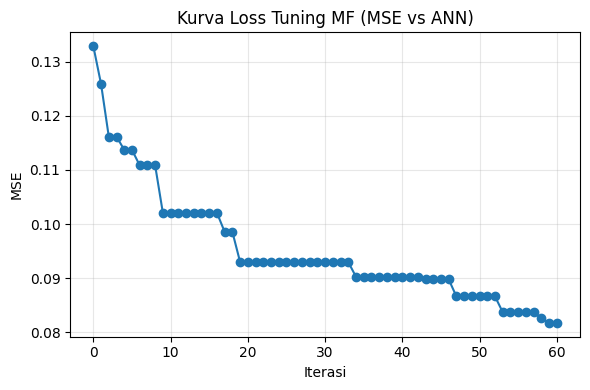

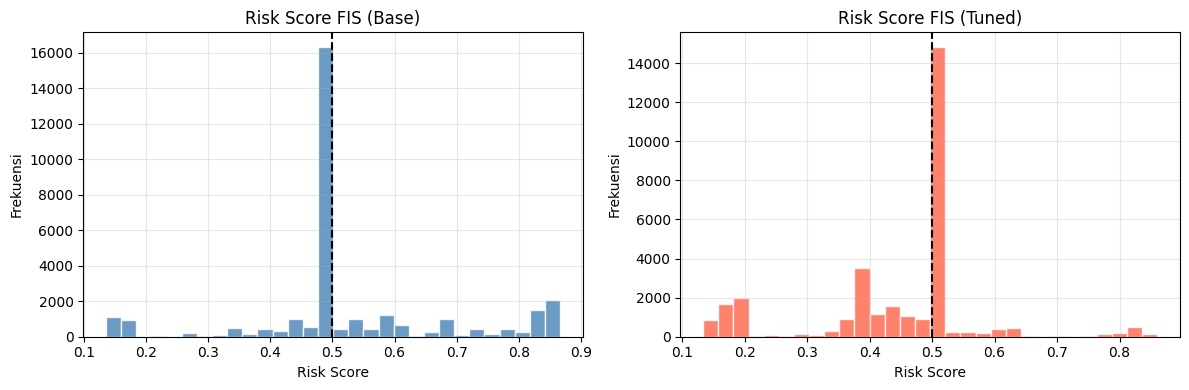

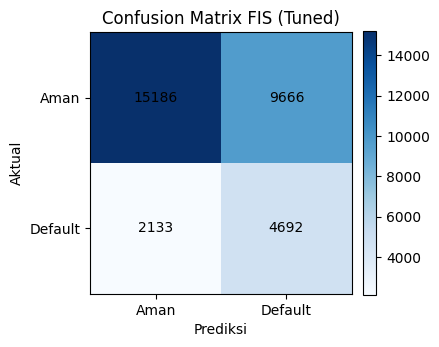

In [43]:
# Plot 1: Loss tuning MF vs ANN
plt.figure(figsize=(6, 4))
plt.plot(range(len(history)), history, marker='o', linewidth=1.5)
plt.title('Kurva Loss Tuning MF (MSE vs ANN)')
plt.xlabel('Iterasi')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/plots/tahap3_tuning_loss.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Distribusi risk score sebelum vs sesudah tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(risk_base, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Risk Score FIS (Base)')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frekuensi')
axes[0].grid(True, alpha=0.3)

axes[1].hist(risk_best, bins=30, color='tomato', alpha=0.8, edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Risk Score FIS (Tuned)')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/plots/tahap3_risk_score_dist.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Confusion matrix FIS tuned
cm = confusion_matrix(target, pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Aman', 'Default'])
ax.set_yticklabels(['Aman', 'Default'])
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix FIS (Tuned)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("../results/plots/tahap3_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [46]:
plt.savefig("../results/plots/tahap3_all_plots.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Visualisasi penting
- Kurva loss tuning MF.
- Distribusi risk score sebelum dan sesudah tuning.
- Confusion matrix FIS tuned.

In [44]:
# Simpan hasil
df_clean["risk_score_tahap3"] = risk_best
df_clean["predicted_tahap3"] = pred_best

df_clean.to_csv("../results/hasil_tahap3_ann_fis.csv", index=False)

with open("../results/mf_params_tahap3_ann.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("Hasil disimpan:")
print("- ../results/hasil_tahap3_ann_fis.csv")
print("- ../results/mf_params_tahap3_ann.json")

Hasil disimpan:
- ../results/hasil_tahap3_ann_fis.csv
- ../results/mf_params_tahap3_ann.json
